In [1]:
!pip install spacy --upgrade

In [2]:
!python -m spacy download en_core_web_sm

/home/michalek/miniconda3/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.1) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 8.0 MB/s  0:00:01a 0:00:01m eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [3]:
import spacy
import en_core_web_sm
import pandas as pd
import seaborn as sns
import numpy as np
import re
import random

/home/michalek/miniconda3/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.1) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [4]:
train_data = pd.read_csv('data/train.csv', header = None,
                         names = ['sentiment', 'id', 'date', 'query', 'user', 'text'], encoding='latin1')

In [5]:
train_data

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


In [6]:
train_data['sentiment'].unique()

array([0, 4])

In [7]:
# sns.countplot(train_data['sentiment']);

In [8]:
np.unique(train_data['sentiment'], return_counts=True)

(array([0, 4]), array([800000, 800000]))

In [9]:
train_data = train_data.drop(['id', 'date', 'query', 'user'], axis=1)
train_data

,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."
...,...,...
1599995,4,Just woke up. Having no school is the best fee...
1599996,4,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,Happy 38th Birthday to my boo of alll time!!! ...


## Train and test data

In [10]:
X = train_data.iloc[:, 1].values
X

array(["@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D",
       "is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!",
       '@Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds',
       ..., 'Are you ready for your MoJo Makeover? Ask me for details ',
       'Happy 38th Birthday to my boo of alll time!!! Tupac Amaru Shakur ',
       'happy #charitytuesday @theNSPCC @SparksCharity @SpeakingUpH4H '],
      dtype=object)

In [12]:
y = train_data.iloc[:, 0].values
y

array([0, 0, 0, ..., 4, 4, 4])

In [13]:
from sklearn.model_selection import train_test_split
X, _, y, _ = train_test_split(X, y, test_size = 0.97)

In [14]:
X

array(['@Niki7a a very good idea ',
       'Wings r one away from the stanley cup!!  ',
       '@saultheturtle, thank you! ', ...,
       'Good morning! (to some good nite) I hope you had an enjoyable weekend ',
       '@SandyFowler Thank you for the very kind words about my latest blog post/story! Glad you enjoyed it! Sending smiles ... ',
       "I hate how Victoria Beckham spells 'colors' like 'colours' &amp; 'favors' like 'favours' "],
      dtype=object)

In [15]:
X.shape

(48000,)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [17]:
X_train.shape, y_train.shape

((38400,), (38400,))

In [18]:
X_test.shape, y_test.shape

((9600,), (9600,))

In [19]:
np.unique(y_train, return_counts=True)

(array([0, 4]), array([19326, 19074]))

In [20]:
np.unique(y_test, return_counts=True)

(array([0, 4]), array([4759, 4841]))

# Preprocessing the data

In [21]:
nlp = spacy.load('en_core_web_sm')
nlp

In [23]:
def preprocessing(sentence):
  sentence = sentence.lower()
  sentence = re.sub(r"@[A-Za-z0-9]+", ' ', sentence)
  sentence = re.sub(r"https?://[A-Za-z0-9./]+", ' ', sentence)
  sentence = sentence.replace('.', '')
  tokens = []
  tokens = [token.text for token in nlp(sentence) if not (token.is_stop or token.like_num or token.is_punct or token.is_space or len(token) == 1)]
  tokens = ' '.join([element for element in tokens])

  return tokens

In [24]:
preprocessing("@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  2 You shoulda got David Carr of Third Day to do it. ;D")

'awww bummer shoulda got david carr day'

In [25]:
X_train_cleaned = [preprocessing(tweet) for tweet in X_train]

In [26]:
len(X_train_cleaned)

38400

In [27]:
for _ in range(10):
  print(X_train_cleaned[random.randint(0, len(X_train_cleaned) - 1)])

hi peter think awesome play carlisle way imagined rock
yay bj lorraine amd baby hahaha
wow day talk blame nice luv
going town today cos lazy yesterday lol gona breakfast
damn youuuuuuu want subway
yes like blipping tunes
left amp union sqi miss em
fail cheer freedoms land watch taken away
congrats bnet cnet aop ftws slightly jealous watch backs lads ladettes
cahhh transferring chino hills bit


In [28]:
X_test_cleaned = [preprocessing(tweet) for tweet in X_test]

## Word cloud

In [29]:
texts = ''
for text in X_train_cleaned:
  texts += ' ' + text

In [30]:
texts

" coffee time tried sending picture morning stayed quot;sending twitpic quot screen forever wrong nita phone stopped allowing send texts keeps failing resting long tough day beautiful wife disapointed jon amp kate trouble internet police sexual harrassment twitter fuckkkk classic course chris speak truth think disappeared answered got iphone touch hello found guys wefollow 5:30am coffee having apple instead 3turnoffwords lets friends time steve found geocache kl bit sweating sure heat walk ummmm probably known oldies lol truly love types left restraunt table air force guys uniform yay watching ass stuck road poorly francis having sleep nite amp hay fever raping real thoit looks like girl threw large shirt pinned legs called dress saying goodbye hubby called giddy hottie calls darn got shortlisted floor job guess coverletter good interview quot;get like storm keeps heading way everyday shelter&quot blue_wolf spare iphones van sorry try glad spread word got 2:2 happy happy amp amazing pe

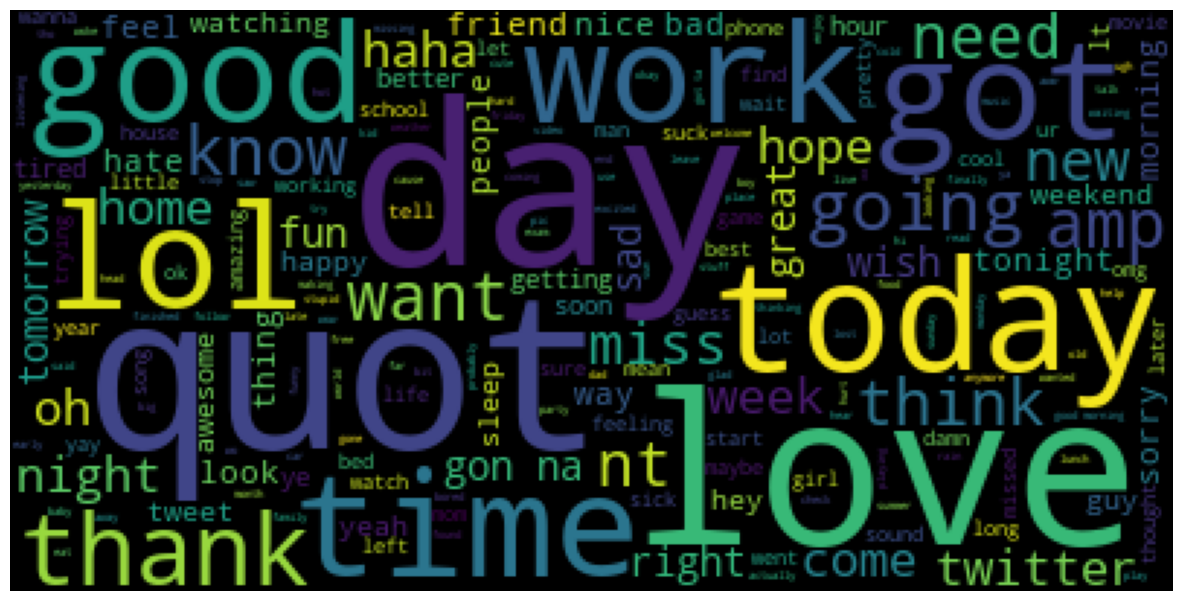

In [31]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
cloud = WordCloud()
cloud = cloud.generate(texts)
plt.figure(figsize=(15,15))
plt.imshow(cloud)
plt.axis('off');

# Detecting languages

In [32]:
!pip install langdetect

In [40]:
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

In [41]:
detect('This is an English text')

'en'

In [42]:
detect('Este é um texto em português')

'pt'

In [43]:
detect('Este es un texto en espanõl')

'es'

In [45]:
languages = []
for text in X_test_cleaned:
    if text != '':
        try:
            languages.append(detect(text))
        except LangDetectException:
            languages.append('unknown')  # Or 'und' for undetermined
    else:
        languages.append('unknown')

In [46]:
np.unique(languages, return_counts=True)

(array(['af', 'ca', 'cs', 'cy', 'da', 'de', 'en', 'es', 'et', 'fi', 'fr',
        'hr', 'hu', 'id', 'it', 'lt', 'lv', 'nl', 'no', 'pl', 'pt', 'ro',
        'sk', 'sl', 'so', 'sq', 'sv', 'sw', 'tl', 'tr', 'unknown', 'vi'],
       dtype='<U7'),
 array([ 534,   53,   21,  143,  136,   19, 6829,   60,  111,   52,  142,
          20,   11,   99,   84,    9,    6,  186,  159,   42,   26,   73,
          28,   40,  292,   20,   82,   71,  159,   20,   59,   14]))

# Sentiment analysis with NLTK

In [47]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/michalek/nltk_data...


True

In [48]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [49]:
nltk_classifier = SentimentIntensityAnalyzer()
nltk_classifier.polarity_scores('I love this food')

{'neg': 0.0, 'neu': 0.323, 'pos': 0.677, 'compound': 0.6369}

In [50]:
nltk_classifier.polarity_scores('I hate this food')

{'neg': 0.649, 'neu': 0.351, 'pos': 0.0, 'compound': -0.5719}

In [51]:
nltk_classifier.polarity_scores('I have this food')

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

In [52]:
X_train_cleaned[0]

'coffee time'

In [53]:
nltk_classifier.polarity_scores(X_train_cleaned[0])

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

In [54]:
X_train_cleaned[20002]

'sitting watching bob strollers come makes miss son seen hours'

In [55]:
nltk_classifier.polarity_scores(X_train_cleaned[20002])

{'neg': 0.151, 'neu': 0.849, 'pos': 0.0, 'compound': -0.1531}

In [56]:
for sentence in X_test:
  print(nltk_classifier.polarity_scores(sentence), ' - ', sentence)

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  #iremember when Alicia Keys first came out and everyone thought she was a lesbian becuz of the braids... SHE'S ONE OF THE SEXIEST NOW! 
{'neg': 0.12, 'neu': 0.707, 'pos': 0.174, 'compound': 0.2481}  -  @Karimx haahahhahahha LMFAOOOO chutiyaaaa  No one! Anyways had hot water + lemon + honey it feels better 
{'neg': 0.281, 'neu': 0.602, 'pos': 0.116, 'compound': -0.6249}  -  @GarveyBen Weekend was good, did sod all   Yours?   Today been a bloody disaster so far though (work).... sodding technology...
{'neg': 0.0, 'neu': 0.734, 'pos': 0.266, 'compound': 0.4404}  -  good night..The day's over i need to sleep na .. 
{'neg': 0.0, 'neu': 0.838, 'pos': 0.162, 'compound': 0.5093}  -  @diehardtryhard was your reply abt my hair? haha! i just had it blow dried for the night. temporary lang 
{'neg': 0.126, 'neu': 0.597, 'pos': 0.277, 'compound': 0.6467}  -  @sarahobrien_ Hey Sarah (: Besides the weather im great!! omg i dreamt of trace cyrus

{'neg': 0.474, 'neu': 0.526, 'pos': 0.0, 'compound': -0.5423}  -  lost ALL cable/internet. no eta. probably monday.  
{'neg': 0.178, 'neu': 0.822, 'pos': 0.0, 'compound': -0.2893}  -  @geekgirl444 apparently so!  I'm falling apart in front of my eyes 
{'neg': 0.285, 'neu': 0.715, 'pos': 0.0, 'compound': -0.6103}  -  stupid rain!! can we move the graduation to some other...climate?  #fb
{'neg': 0.0, 'neu': 0.662, 'pos': 0.338, 'compound': 0.8809}  -  Wow! Just finished watching the Google Wave demo... AMAZING! Buy your stocks now! Its a game changer  Check it out http://wave.google.com/
{'neg': 0.052, 'neu': 0.481, 'pos': 0.467, 'compound': 0.9042}  -  Wow, this is one hard mattress. I hope I get some sleep. Might have better luck on the couch. Yikes. 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  up &amp; at it. hanging out around the house, then work at 5ish 
{'neg': 0.111, 'neu': 0.889, 'pos': 0.0, 'compound': -0.3612}  -  @janellewilson I know what you mean. And just rea

{'neg': 0.0, 'neu': 0.685, 'pos': 0.315, 'compound': 0.717}  -  @niomh ohh that's soo cool! i always wanted to meet new friends all around the world! 
{'neg': 0.174, 'neu': 0.826, 'pos': 0.0, 'compound': -0.2755}  -  Ugh... Wishbone Ranch Dressing does NOT taste like ranch dressing. SMDH 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  @dancer4lifex .......forget about it? 
{'neg': 0.0, 'neu': 0.752, 'pos': 0.248, 'compound': 0.6476}  -  On my way to @bethaaany_x house to collect her  then goin to cinema&amp;shopping! xoxo
{'neg': 0.122, 'neu': 0.782, 'pos': 0.095, 'compound': -0.2023}  -  @iVACash i believe u. lol kids jus aint in my plans yet ..gimme 6 yrs &amp; we'll have lil bri's n shit runnin round here  0oh boy..cant wait
{'neg': 0.204, 'neu': 0.796, 'pos': 0.0, 'compound': -0.5904}  -  @punkrockchick84 idlewild have afew gd songs aswell OMG IM GUNA CRY THO  CANT GO WOLVES ANYMORE
{'neg': 0.0, 'neu': 0.653, 'pos': 0.347, 'compound': 0.8143}  -  Now my daily FF links ar

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  @chibialfa I need something commercial to keep me going  hihihihi
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  @aniqa_x same! need to get an A at AS, cuz i KNOW i won't be able to get As in A2 chem.  i need a B overall... not gonna happen!
{'neg': 0.0, 'neu': 0.59, 'pos': 0.41, 'compound': 0.8765}  -  @jordanknight hey jordan, iÂ´m not at this pic, but iÂ´m also from germany. hope i win 
{'neg': 0.195, 'neu': 0.67, 'pos': 0.134, 'compound': -0.2718}  -  @Muffyn  it wasn't. A wreck it was a smidgeon of paint that's running my ass 240
{'neg': 0.0, 'neu': 0.661, 'pos': 0.339, 'compound': 0.4738}  -  @EqCollections Will do! Thank you so much! 
{'neg': 0.0, 'neu': 0.444, 'pos': 0.556, 'compound': 0.3612}  -  @ExtraOrdinaryy Thank you 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  Having a minor freakout.. 
{'neg': 0.117, 'neu': 0.883, 'pos': 0.0, 'compound': -0.4926}  -  Just home from work (7pm) - long day -

{'neg': 0.0, 'neu': 0.624, 'pos': 0.376, 'compound': 0.8633}  -  @crazy_moon Haha! I get what you mean  Especially when you're surrounded by fangirls XD *dies at ohno top secret gif*
{'neg': 0.102, 'neu': 0.766, 'pos': 0.132, 'compound': 0.1744}  -  @UniquelyBrownPC lol i knew it! preciate it ma'am. i might not be good enough to get a car tho  not yet at least
{'neg': 0.0, 'neu': 0.506, 'pos': 0.494, 'compound': 0.5994}  -  Working again on a beautiful day 
{'neg': 0.131, 'neu': 0.804, 'pos': 0.065, 'compound': -0.3182}  -  Either Apple or UPS are incapable of handling tracking data. Can't track my MacBook with my reference number 
{'neg': 0.375, 'neu': 0.625, 'pos': 0.0, 'compound': -0.7783}  -  @demiDisaster lame ): pe needs to be forever&lt;3  and then ugh... no more pe together? &lt;/3
{'neg': 0.156, 'neu': 0.463, 'pos': 0.381, 'compound': 0.5962}  -  @costa0692 - damn I shoulda gone! I had doctors though  sounds funny!   Dammmnn! Lol x
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compoun

{'neg': 0.196, 'neu': 0.804, 'pos': 0.0, 'compound': -0.296}  -  Missing my papa. Her big baby is so far away 
{'neg': 0.157, 'neu': 0.588, 'pos': 0.255, 'compound': 0.25}  -  @MagicalEmi i sure hope so. i thot the anime ending was disappointing until i saw the manga ending. 
{'neg': 0.0, 'neu': 0.508, 'pos': 0.492, 'compound': 0.4404}  -  @CocaBeenSlinky @suzysmiles Thanks guys  x x x
{'neg': 0.0, 'neu': 0.616, 'pos': 0.384, 'compound': 0.6808}  -  Good morning all. A special &quot;hello&quot; goes to D-Duck today. ((((hugs)))) xxxx 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  Is off to work 
{'neg': 0.0, 'neu': 0.569, 'pos': 0.431, 'compound': 0.5837}  -  @JessieCouture32 hey sweetie !! how r u? 
{'neg': 0.366, 'neu': 0.407, 'pos': 0.227, 'compound': -0.3321}  -  Im almost ready... I feel like shit 
{'neg': 0.187, 'neu': 0.535, 'pos': 0.278, 'compound': 0.3751}  -  alright good night for now :C (LOVE YA) idk Be safe this night dont roll over and break another arm 
{'neg

{'neg': 0.0, 'neu': 0.259, 'pos': 0.741, 'compound': 0.8213}  -  @YoungQ hope sasha's gift is okay!!! 
{'neg': 0.061, 'neu': 0.761, 'pos': 0.178, 'compound': 0.3182}  -  @RobertHough Hmmm well considering we are non profit that would be hard - but we can look for donations 
{'neg': 0.105, 'neu': 0.81, 'pos': 0.086, 'compound': -0.1027}  -  @hondita I made it home just fine. I wouldn't have pulled over on a busy highway with no bushes to speak of 
{'neg': 0.0, 'neu': 0.543, 'pos': 0.457, 'compound': 0.7739}  -  @BeauSchembekler I had an elantra GT and I loved it... Got totalled 
{'neg': 0.0, 'neu': 0.83, 'pos': 0.17, 'compound': 0.7279}  -  The butterfly came out of it's cocoon but it's not looking so good.  Wings are all folded up and there is a puddle of goo below it.
{'neg': 0.0, 'neu': 0.766, 'pos': 0.234, 'compound': 0.6467}  -  @one_call: Day 26!!  But im about 4 hours early cuz i wanna be in the frnt lol
{'neg': 0.076, 'neu': 0.811, 'pos': 0.114, 'compound': 0.1779}  -  still wor

# Sentiment analysis with TF-IDF